In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['image.cmap'] = 'bwr'

from src import *

In [3]:
Y = list(range(2**9))

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

In [4]:
def get_hatPyi(Pyi, scale=1.0):
    # pixel-level probability is predicted with a gaussian noise at the logits
    def hatpyi(x):
        z = sp.special.logit(Pyi[x])
        zhat = np.random.RandomState(x).normal(z, scale=scale)
        return sp.special.expit(zhat)

    hatPyi = [hatpyi(x) for x in np.arange(2**9)]
    hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

    return hatPyi, hatPy

loss_01 = lambda y, y_hat: 1-int(y == y_hat)
loss_acc = lambda y, y_hat: 1 - (int2img(y) == int2img(y_hat)).mean()
loss_dsc = lambda y, y_hat: 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum()+1e-3)
loss_sve = lambda y, y_hat: (int2img(y).sum(dtype=float) - int2img(y_hat).sum(dtype=float))**2 / 9

In [5]:
def get_h_01(hatPy):
    return lambda x: np.argmax(hatPy[x])

def get_h_dice(hatPy):
    hatRy_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

    return lambda x: np.argmin(hatRy_dice[x])

# Experiment 4

Hypothesis:

- Uniform $\mathcal{X}$ distribution (shouldn't impact the results)
- The ground truth $y$ images are drawn from handcrafted probability distributions
- Output probability distribution is **approximately** known, i.e., $\forall y$, we have $$ \hat{P}(Y=y|X=x) \approx P(Y=y|X=x) $$

## Singleton distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly and is assigned a high probability (>0.5, uniformly sampled). This is the expert segmentation, and its probability is the experts' confidence level (maybe agreement?)
<!-- 2. Two other segmentations, $y^{(1)}$ and $y^{(2)}$, that differ from the expert segmentation by one pixel are assigned equal probability values ($P(Y=y^{(1)}|X=x) = P(Y=y^{(2)}|X=x)$) such that $$ P(Y=y^{\star}|X=x) + P(Y=y^{(1)}|X=x) + P(Y=y^{(2)}|X=x) = 1 $$ -->
2. One other segmentation, $y^{(1)}$, that differs from the expert segmentation by one pixel is assigned a probability value $$ P(Y=y^{(1)}|X=x) = 1 - P(Y=y^{\star}|X=x) $$

In [6]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)
    p_y_star = (np.random.RandomState(x).rand() + 1) / 2  # in [0.5, 1)

    y_1 = y_star ^ (2 ** np.random.RandomState(x).randint(0, 9))  # flip a random bit
    # y_2 = y_star ^ (2 ** np.random.RandomState((2**9)+x).randint(0, 9))

    # p_remaining = 1 - p_y_star
    # p_y_1 = np.random.RandomState(x**2).rand() * p_remaining
    # p_y_2 = p_remaining - p_y_1
    p_y_1 = 1 - p_y_star

    Py_x = np.zeros(2**9)
    Py_x[y_star] += p_y_star
    Py_x[y_1] += p_y_1
    # Py_x[y_2] += p_y_2
    Py.append(Py_x)

    # Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1 + int2img(y_2) * p_y_2
    Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

hatPyi, hatPy = get_hatPyi(Pyi)

### Example

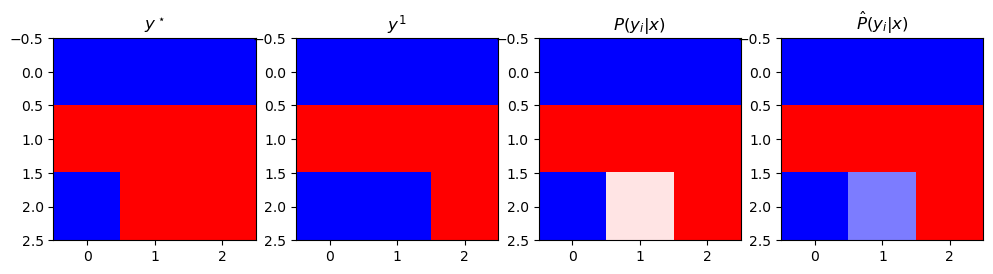

In [7]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 4)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])
y_1 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(int2img(y_1))
axs[1].set_title(r'$y^1$')

axs[2].imshow(Pyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$P(y_i|x)$')

axs[3].imshow(hatPyi[x], vmin=0, vmax=1)
axs[3].set_title(r'$\hat{P}(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

#### RC Curves

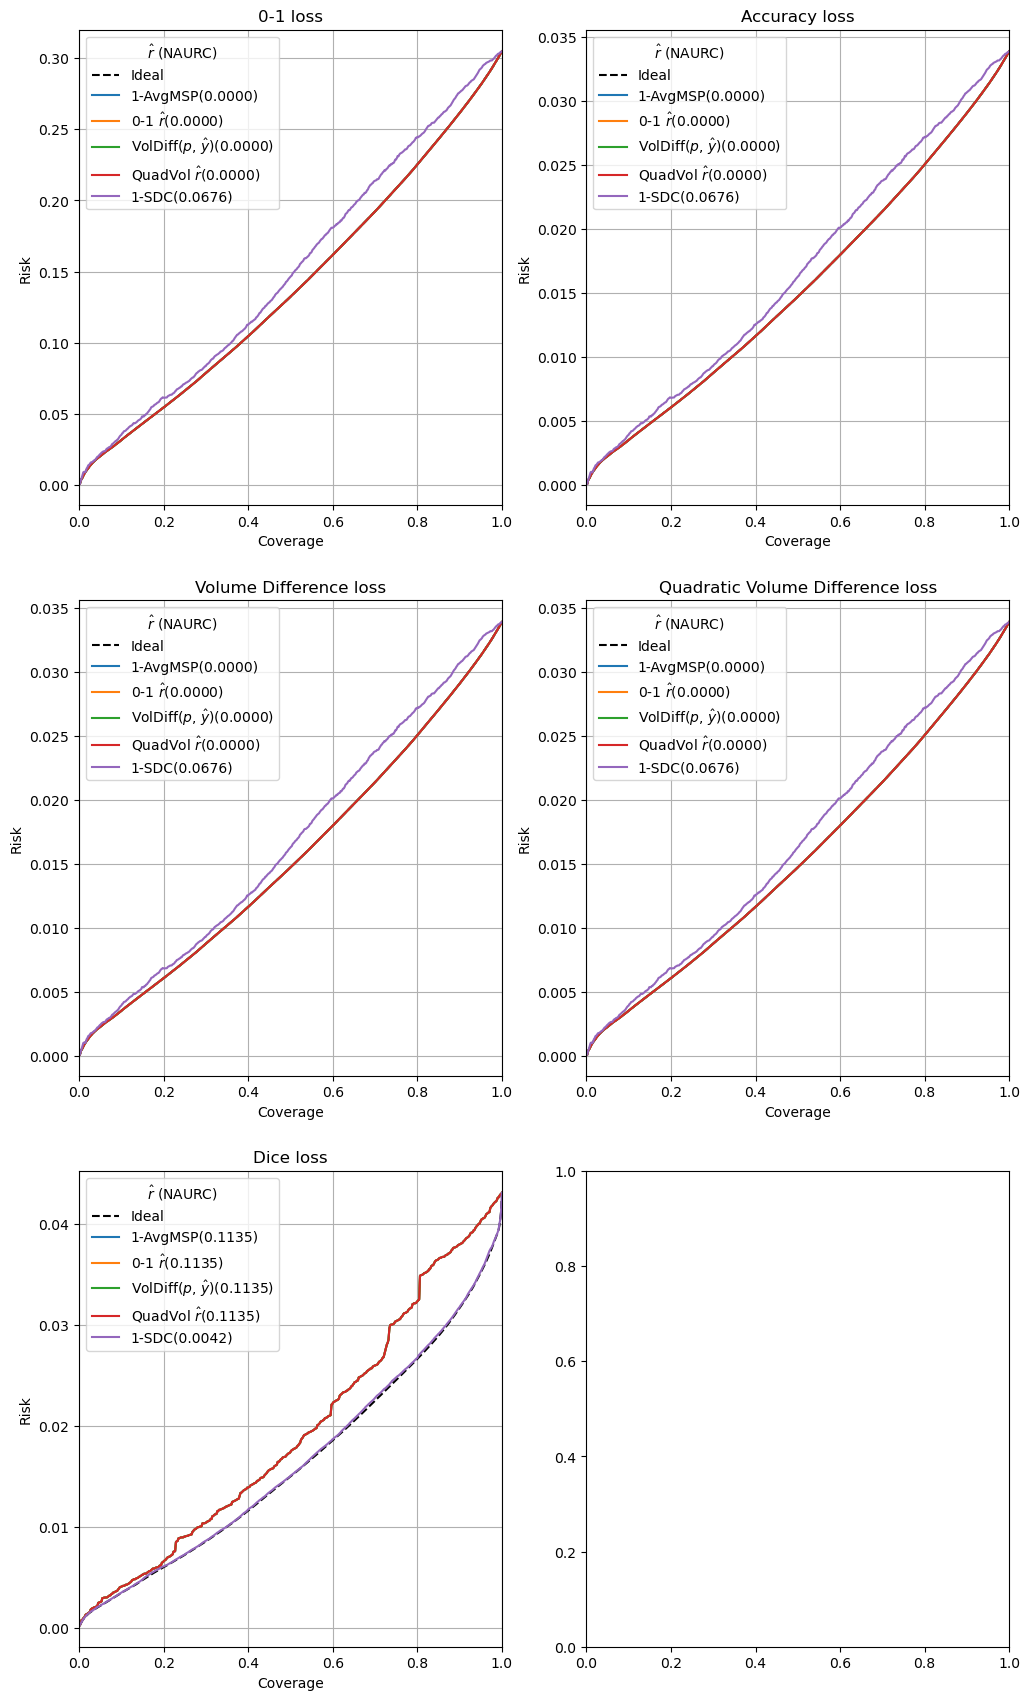

In [8]:
h = get_h_01(hatPy)

all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

#### Variable noise

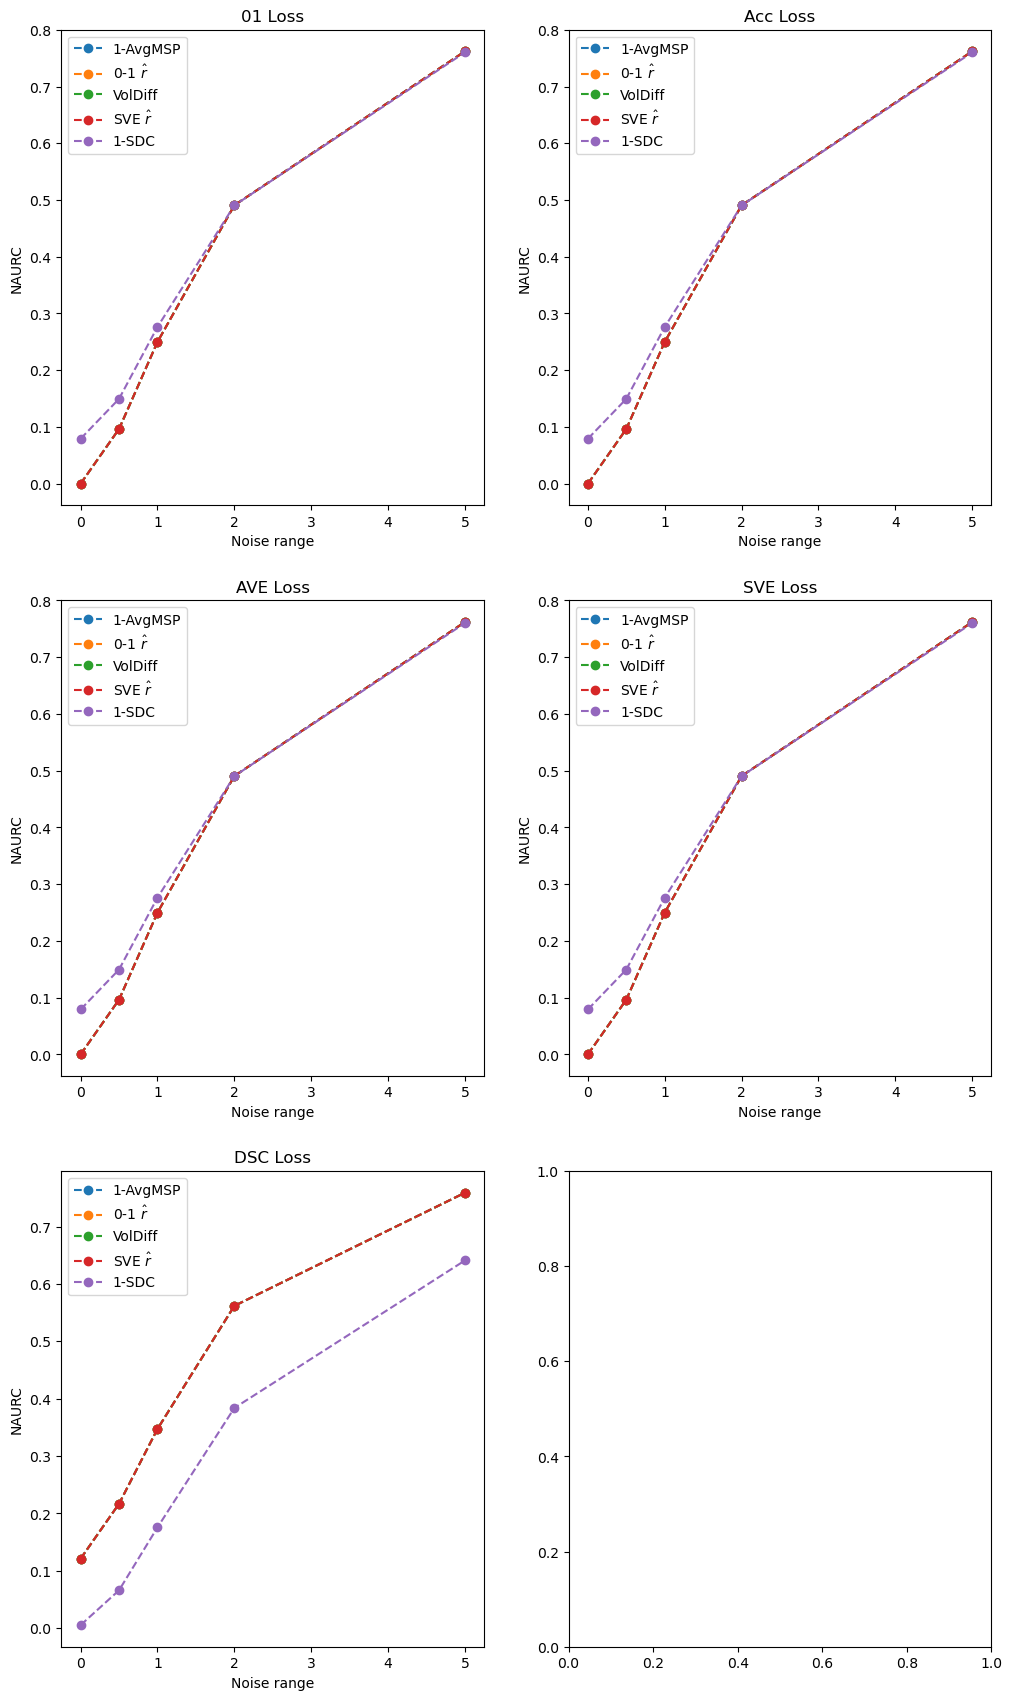

In [9]:
all_plots = [plot_noise_01_loss, plot_noise_accuracy_loss, plot_noise_voldiff_loss, plot_noise_quadvoldiff_loss, plot_noise_dice_loss]

fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_noise, ax in zip(all_plots, axs.flatten()):
    plot_noise(get_h_01, Py, Pyi, ax=ax)
plt.show()

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [10]:
# h = lambda x: np.argmin(hatRy_dice[x])
h = get_h_dice(hatPy)

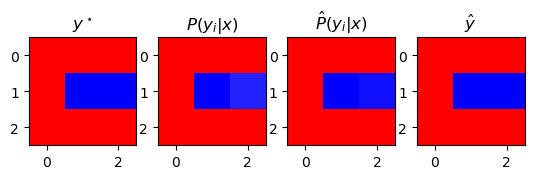

In [11]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 4)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

axs[3].imshow(int2img(y_hat))
axs[3].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

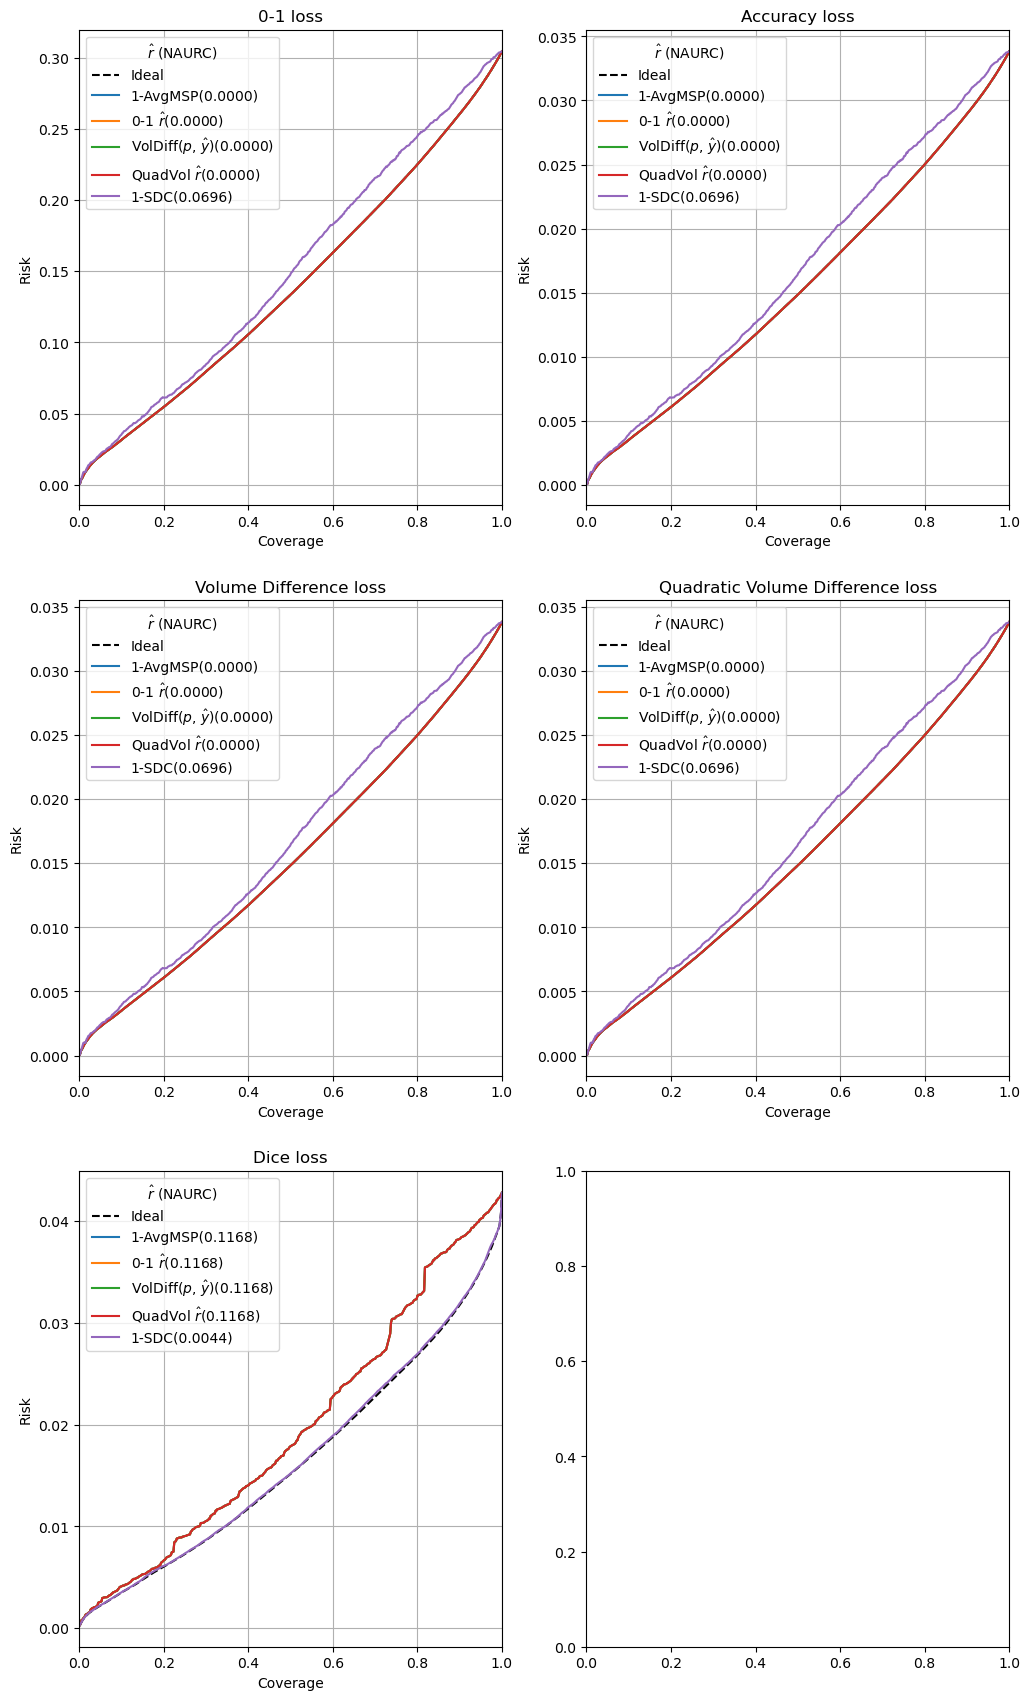

In [12]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

#### Variable noise

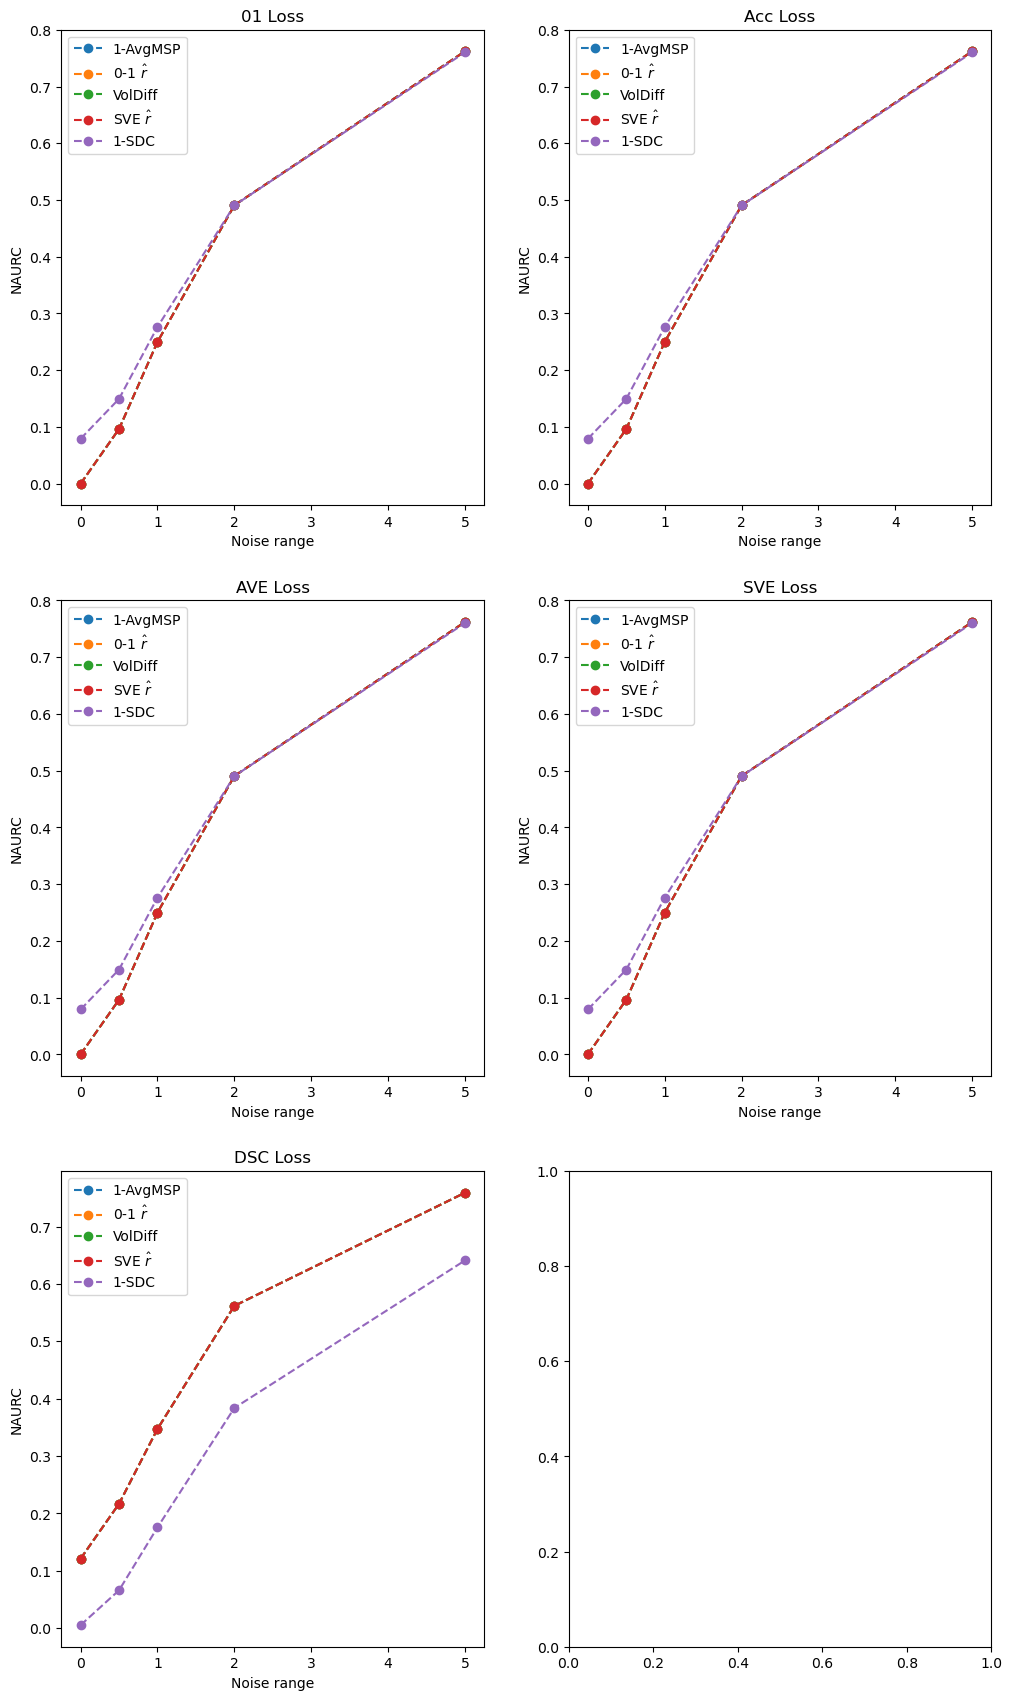

In [13]:
all_plots = [plot_noise_01_loss, plot_noise_accuracy_loss, plot_noise_voldiff_loss, plot_noise_quadvoldiff_loss, plot_noise_dice_loss]

fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_noise, ax in zip(all_plots, axs.flatten()):
    plot_noise(get_h_01, Py, Pyi, ax=ax)
plt.show()

## Cherry-picked distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly and is assigned a high probability (>0.34, uniformly sampled). This is the expert segmentation, and its probability is the experts' confidence level (maybe agreement?)
2. Two other segmentations, $y^{(1)}$ and $y^{(2)}$, that differ from the expert segmentation by one pixel are assigned equal probability values ($P(Y=y^{(1)}|X=x) = P(Y=y^{(2)}|X=x)$) such that $$ P(Y=y^{\star}|X=x) + P(Y=y^{(1)}|X=x) + P(Y=y^{(2)}|X=x) = 1 $$
<!-- 2. One other segmentation, $y^{(1)}$, that differs from the expert segmentation by one pixel is assigned a probability value $$ P(Y=y^{(1)}|X=x) = 1 - P(Y=y^{\star}|X=x) $$ -->

In [14]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)
    p_y_star = (np.random.RandomState(x).rand() * (1 - 0.34)) + 0.34  # in [0.34, 1)

    y_1 = y_star ^ (2 ** np.random.RandomState(x).randint(0, 9))  # flip a random bit
    y_2 = y_star ^ (2 ** np.random.RandomState((2**9)+x).randint(0, 9))

    p_remaining = 1 - p_y_star
    p_y_1 = np.random.RandomState(x**2).rand() * p_remaining
    p_y_2 = p_remaining - p_y_1

    Py_x = np.zeros(2**9)
    Py_x[y_star] += p_y_star
    Py_x[y_1] += p_y_1
    Py_x[y_2] += p_y_2
    Py.append(Py_x)

    Pyi_x = int2img(y_star) * p_y_star + int2img(y_1) * p_y_1 + int2img(y_2) * p_y_2
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

hatPyi, hatPy = get_hatPyi(Pyi)

### Example

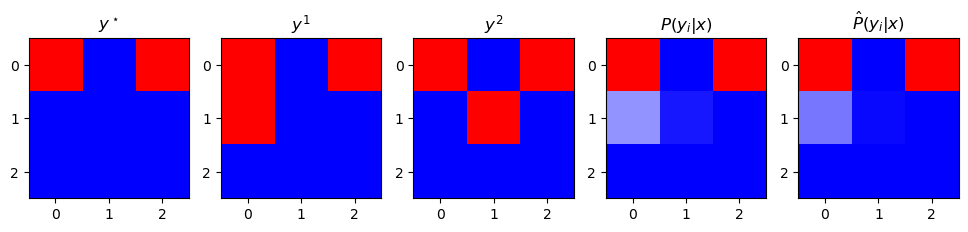

In [15]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 5)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])
y_1, y_2 = np.array(range(2**9))[(Py[x] > 0) & (Py[x] < Py[x][y_star])]

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(int2img(y_1))
axs[1].set_title(r'$y^1$')

axs[2].imshow(int2img(y_2))
axs[2].set_title(r'$y^2$')

axs[3].imshow(Pyi[x], vmin=0, vmax=1)
axs[3].set_title(r'$P(y_i|x)$')

axs[4].imshow(hatPyi[x], vmin=0, vmax=1)
axs[4].set_title(r'$\hat{P}(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

#### RC Curves

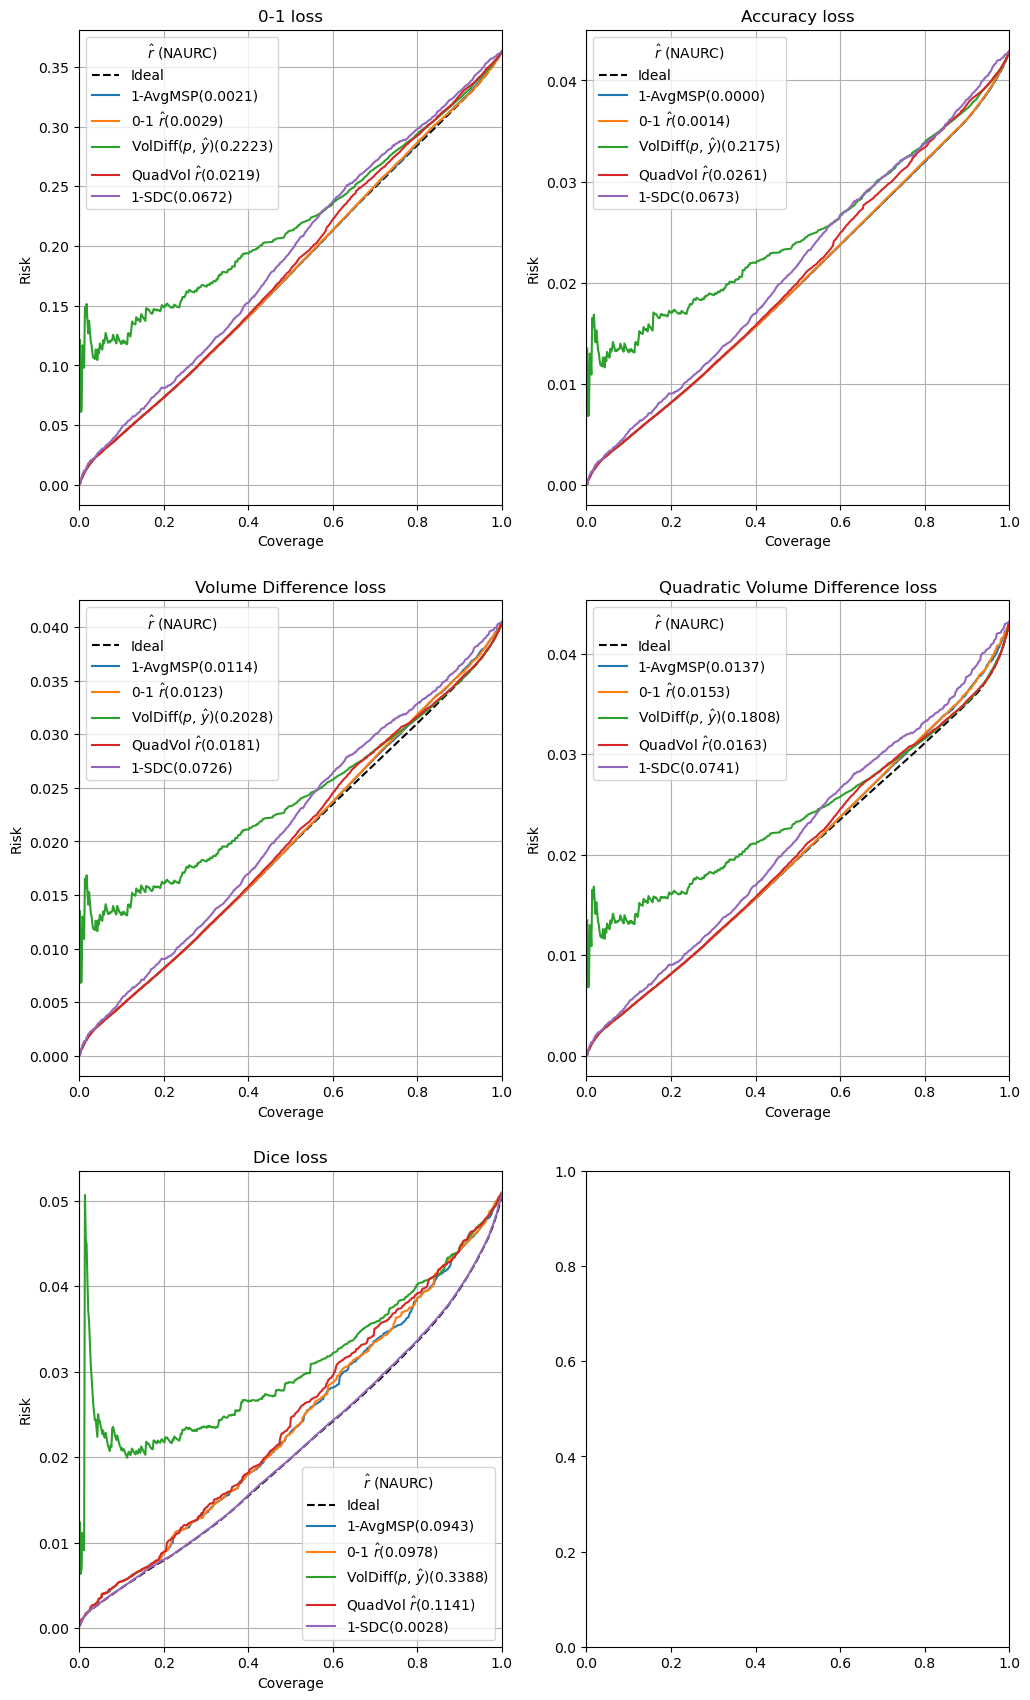

In [16]:
h = get_h_01(hatPy)

all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

Note that 0-1, accuracy, AVE, and SVE have very similar behavior for the proposed probability distribution.

#### Variable noise

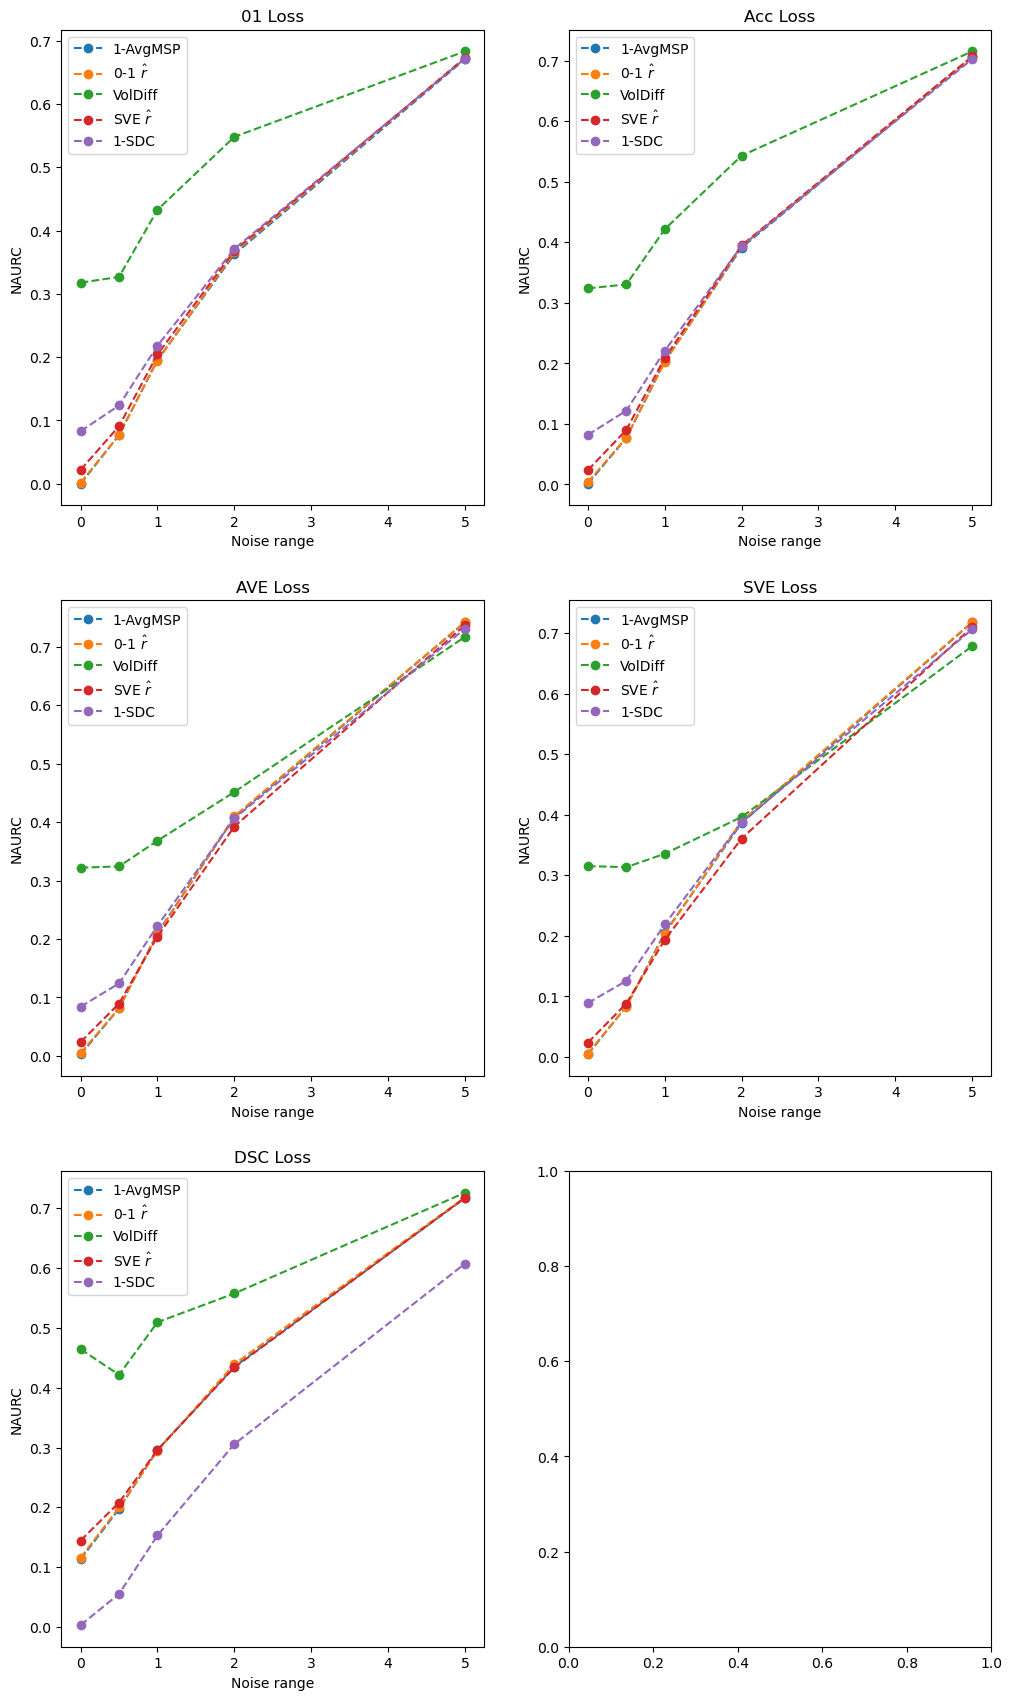

In [17]:
all_plots = [plot_noise_01_loss, plot_noise_accuracy_loss, plot_noise_voldiff_loss, plot_noise_quadvoldiff_loss, plot_noise_dice_loss]

fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_noise, ax in zip(all_plots, axs.flatten()):
    plot_noise(get_h_01, Py, Pyi, ax=ax)
plt.show()

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [18]:
# h = lambda x: np.argmin(hatRy_dice[x])
h = get_h_dice(hatPy)

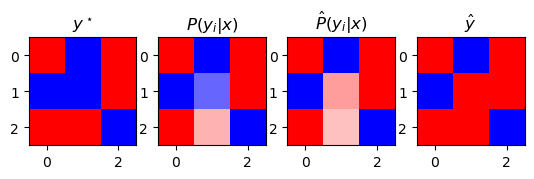

In [19]:
## EXAMPLE
x = np.random.choice(2**9)
y_star = np.argmax(Py[x])
y_hat = h(x)

fig, axs = plt.subplots(1, 4)

axs[0].imshow(int2img(y_star))
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

axs[3].imshow(int2img(y_hat))
axs[3].set_title(r'$\hat{y}$')

plt.show()

#### RC Curves

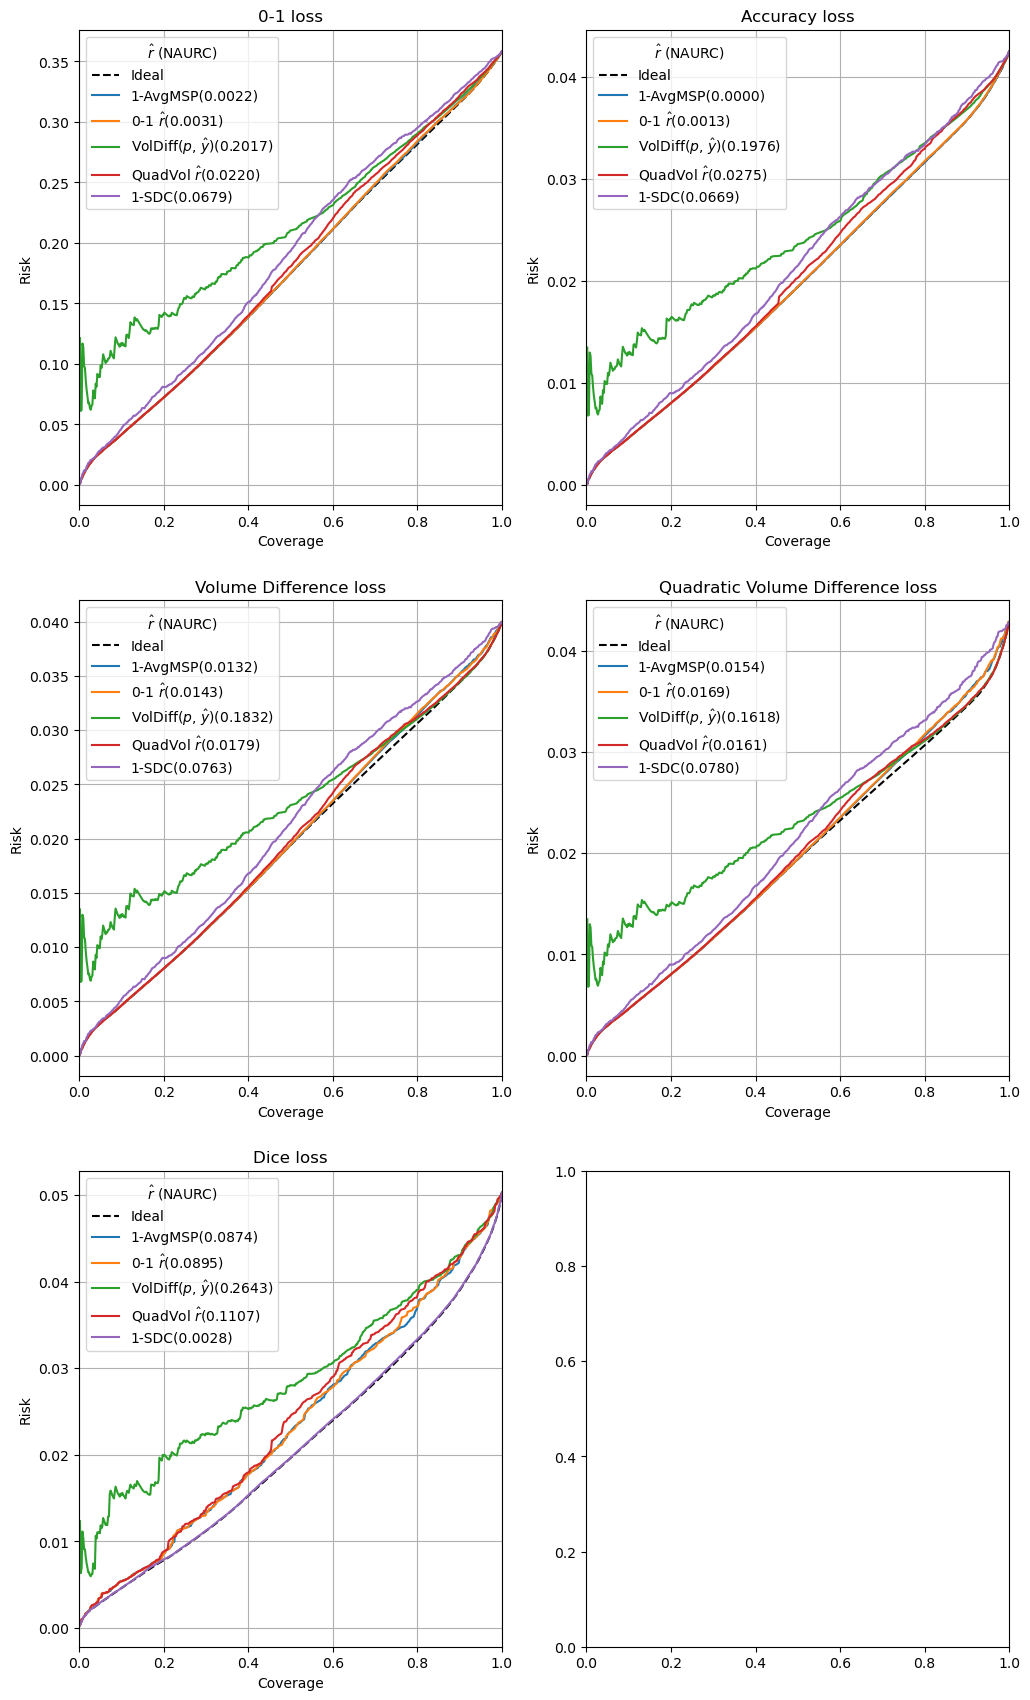

In [20]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

#### Variable noise

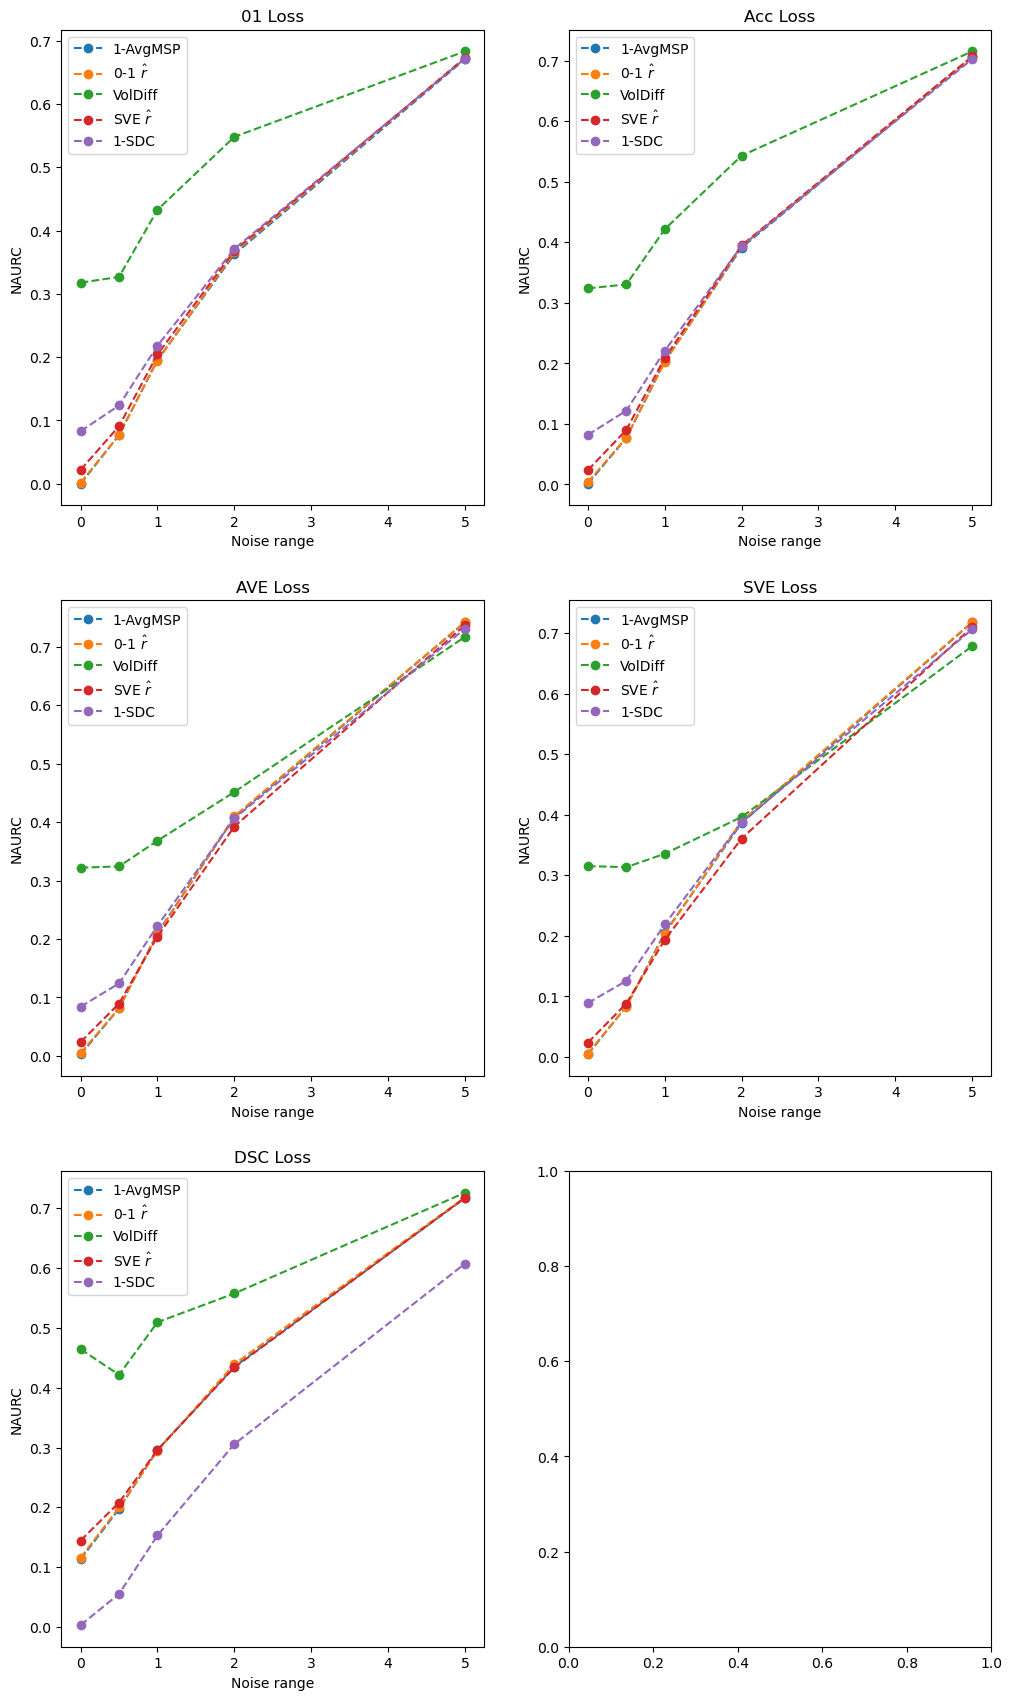

In [21]:
all_plots = [plot_noise_01_loss, plot_noise_accuracy_loss, plot_noise_voldiff_loss, plot_noise_quadvoldiff_loss, plot_noise_dice_loss]

fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_noise, ax in zip(all_plots, axs.flatten()):
    plot_noise(get_h_01, Py, Pyi, ax=ax)
plt.show()

## Dice-based distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is constructed as:

1. The most probable segmentation $y^{\star}$ is drawn uniformly, and represents the expert segmentation
2. A probability mass is assigned to all images based on their Dice score with respect to $y^{\star}$ 
3. Each segmentation's probability, thus, is defined as $$ P(Y=y|X=x) = \frac{DSC(y,y^\star)}{\sum_{y'\in\mathcal{Y}} DSC(y',y^\star)} $$

In [22]:
# build probability distribution and estimate marginal
Py = list()
Pyi = list()

Y_images = [int2img(y) for y in range(2**9)]

for x in range(2**9):
    y_star = np.random.RandomState(x).randint(1, 2**9)

    My_x = (1 - AllDiceLosses[y_star])

    Py_x = My_x / np.sum(My_x)
    Py.append(Py_x)

    Pyi_x = sum([y_image * p for y_image, p in zip(Y_images, Py_x)])
    Pyi.append(Pyi_x)
Py = np.stack(Py)
Pyi = np.stack(Pyi)

hatPyi, hatPy = get_hatPyi(Pyi)
hatRy_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])

### Example

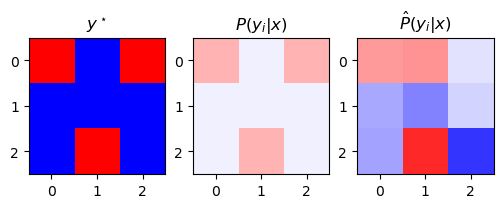

In [23]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(6,6)

y_star = np.argmax(Py[x])

axs[0].imshow(int2img(y_star), vmin=0, vmax=1)
axs[0].set_title(r'$y^\star$')

axs[1].imshow(Pyi[x], vmin=0, vmax=1)
axs[1].set_title(r'$P(y_i|x)$')

axs[2].imshow(hatPyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$\hat{P}(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [24]:
# most probable output
h = lambda x: np.argmax(hatPy[x])

#### RC Curves

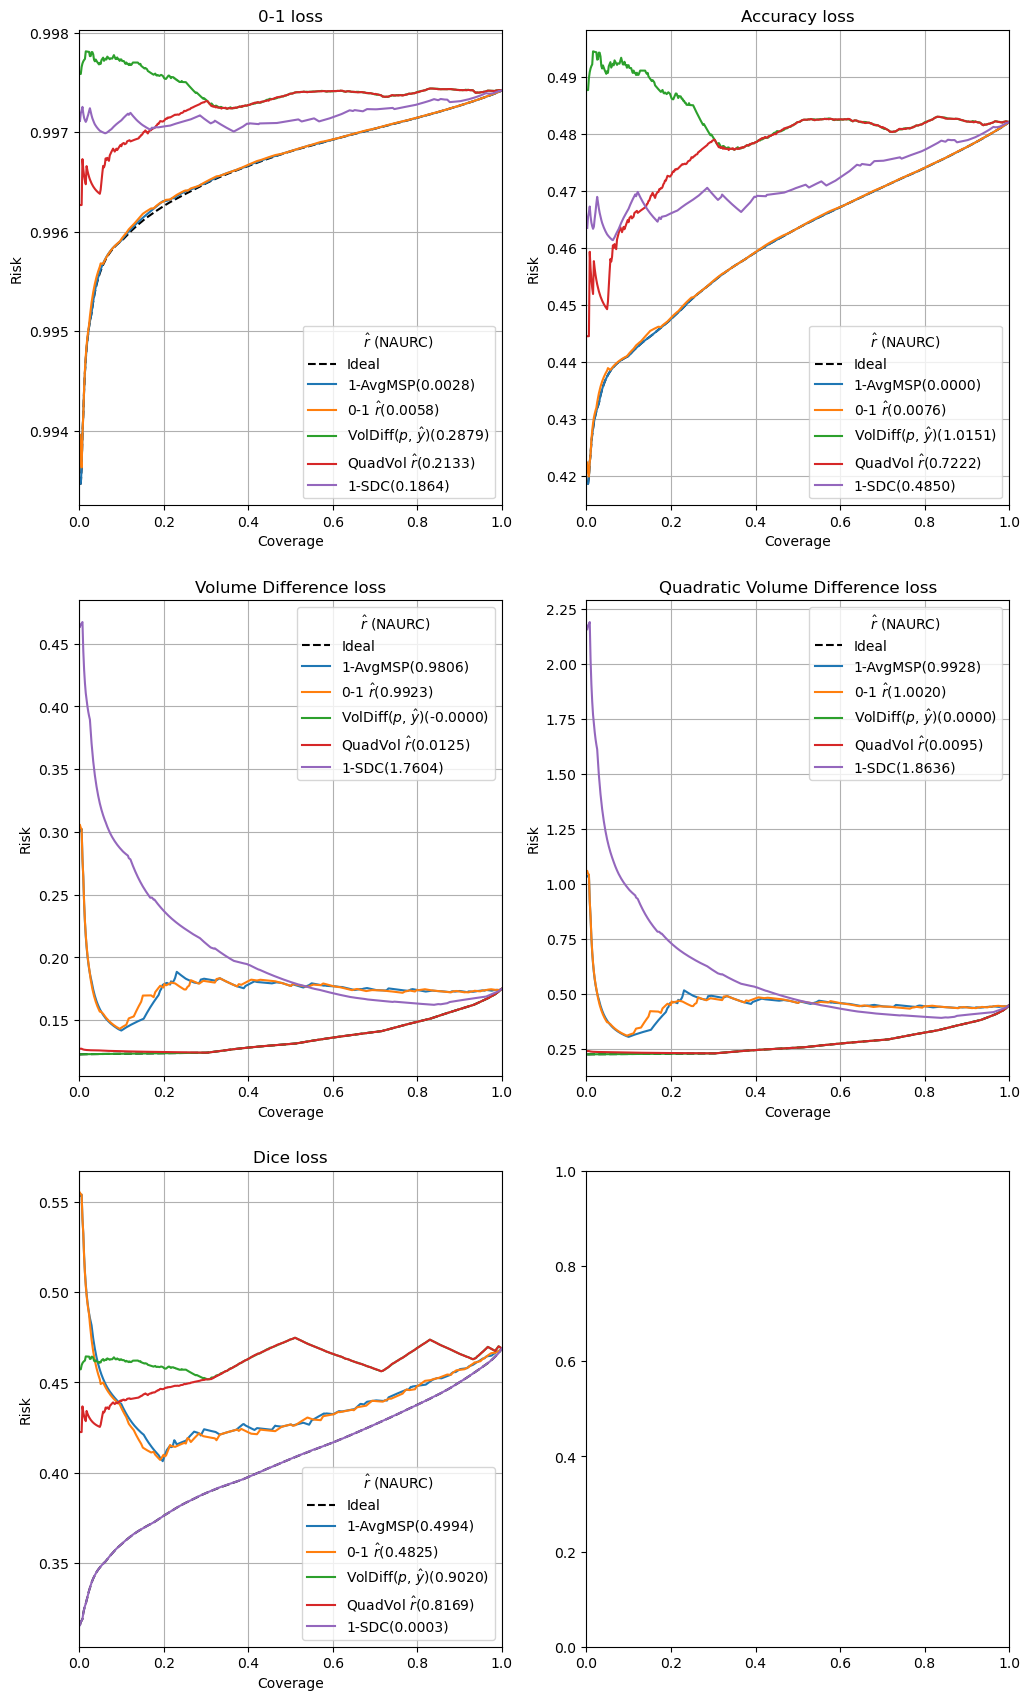

In [25]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

## Beta distribution

For each input image $x \in \mathcal{X}$, the output probability distribution $P(Y=y|X=x)$ is an extremely assymetric beta distribution, with $a=0.01$ and $b=10$.

In [26]:
Py = np.array([np.random.RandomState(x).beta(0.01, 10.0, 2**9) for x in range(2**9)])
Py = np.array([Py[x] / Py[x].sum() for x in range(2**9)])

Pyi = np.array([np.array([int2img(y) * Py[x,y] for y in range(2**9)]).sum(0) for x in range(2**9)])

hatPyi, hatPy = get_hatPyi(Pyi)
hatRy_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])

### Example

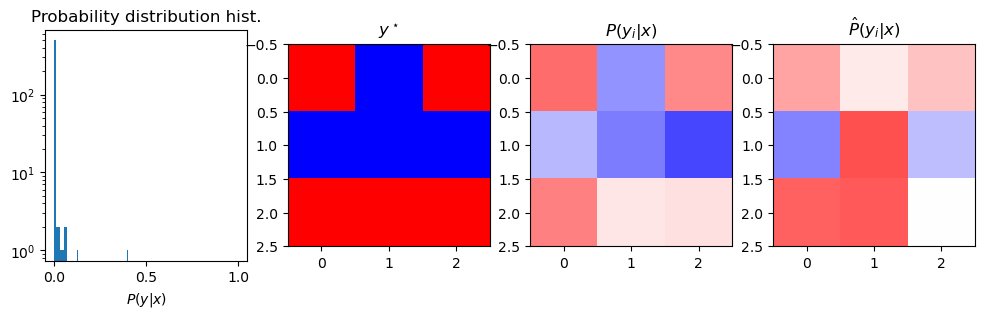

In [27]:
x = np.random.choice(2**9)

fig, axs = plt.subplots(1, 4)
fig.set_size_inches(12,3)

y_star = np.argmax(Py[x])

axs[0].hist(Py[x], bins=np.linspace(0,1,100))
axs[0].set_yscale('log')
axs[0].set_title(r'Probability distribution hist.')
axs[0].set_xlabel(r'$P(y|x)$')

axs[1].imshow(int2img(y_star))
axs[1].set_title(r'$y^\star$')

axs[2].imshow(Pyi[x], vmin=0, vmax=1)
axs[2].set_title(r'$P(y_i|x)$')

axs[3].imshow(hatPyi[x], vmin=0, vmax=1)
axs[3].set_title(r'$\hat{P}(y_i|x)$')

plt.show()

### 0-1 & accuracy ideal model

The ideal model for the 0-1 loss is $$ h(x) = \arg\max_{\hat{y}} \, P(Y=\hat{y}|X=x). $$

In [28]:
# most probable output
h = lambda x: np.argmax(hatPy[x])

#### RC Curves

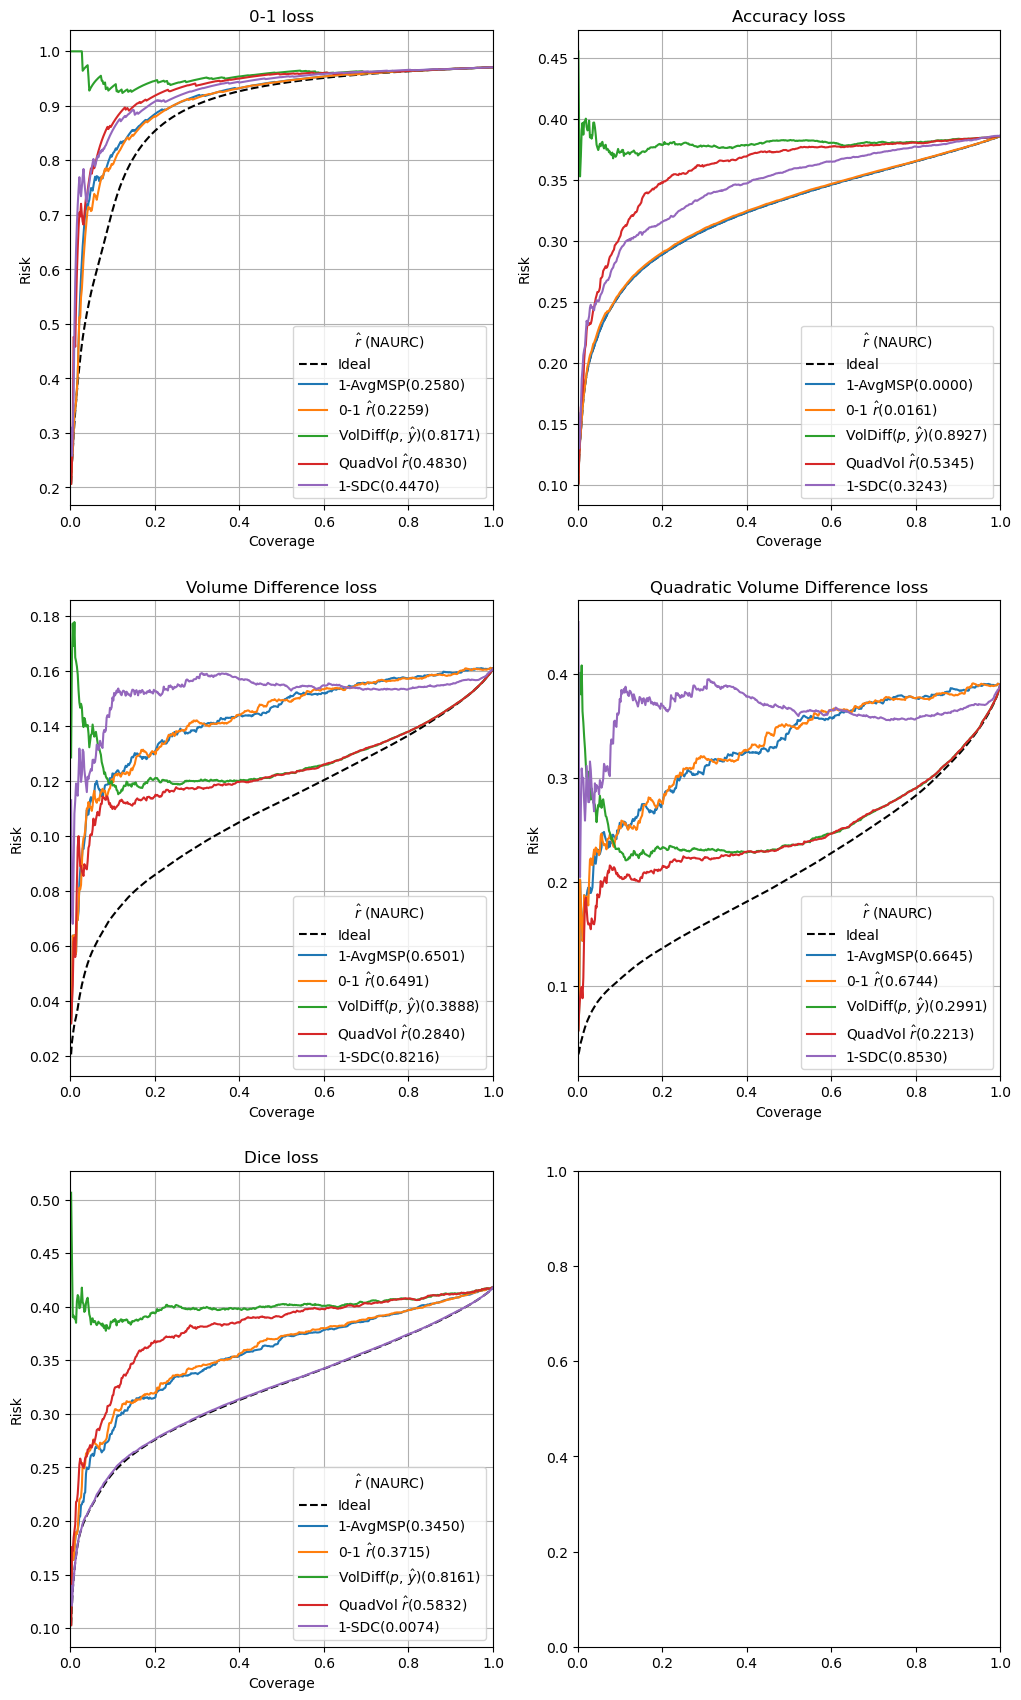

In [29]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

### Max Dice model

The ideal model for the Dice loss is the one that minimizes the conditional risk $ h(x) = \arg\min_{\hat{y}} r_{DSC}(x,\hat{y}) $, where $$ r_{DSC}(x,\hat{y}) = \sum_y P(Y=y|X=x) DSC(y,\hat{y}) . $$

In [30]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(hatRy_dice[x])

#### RC Curves

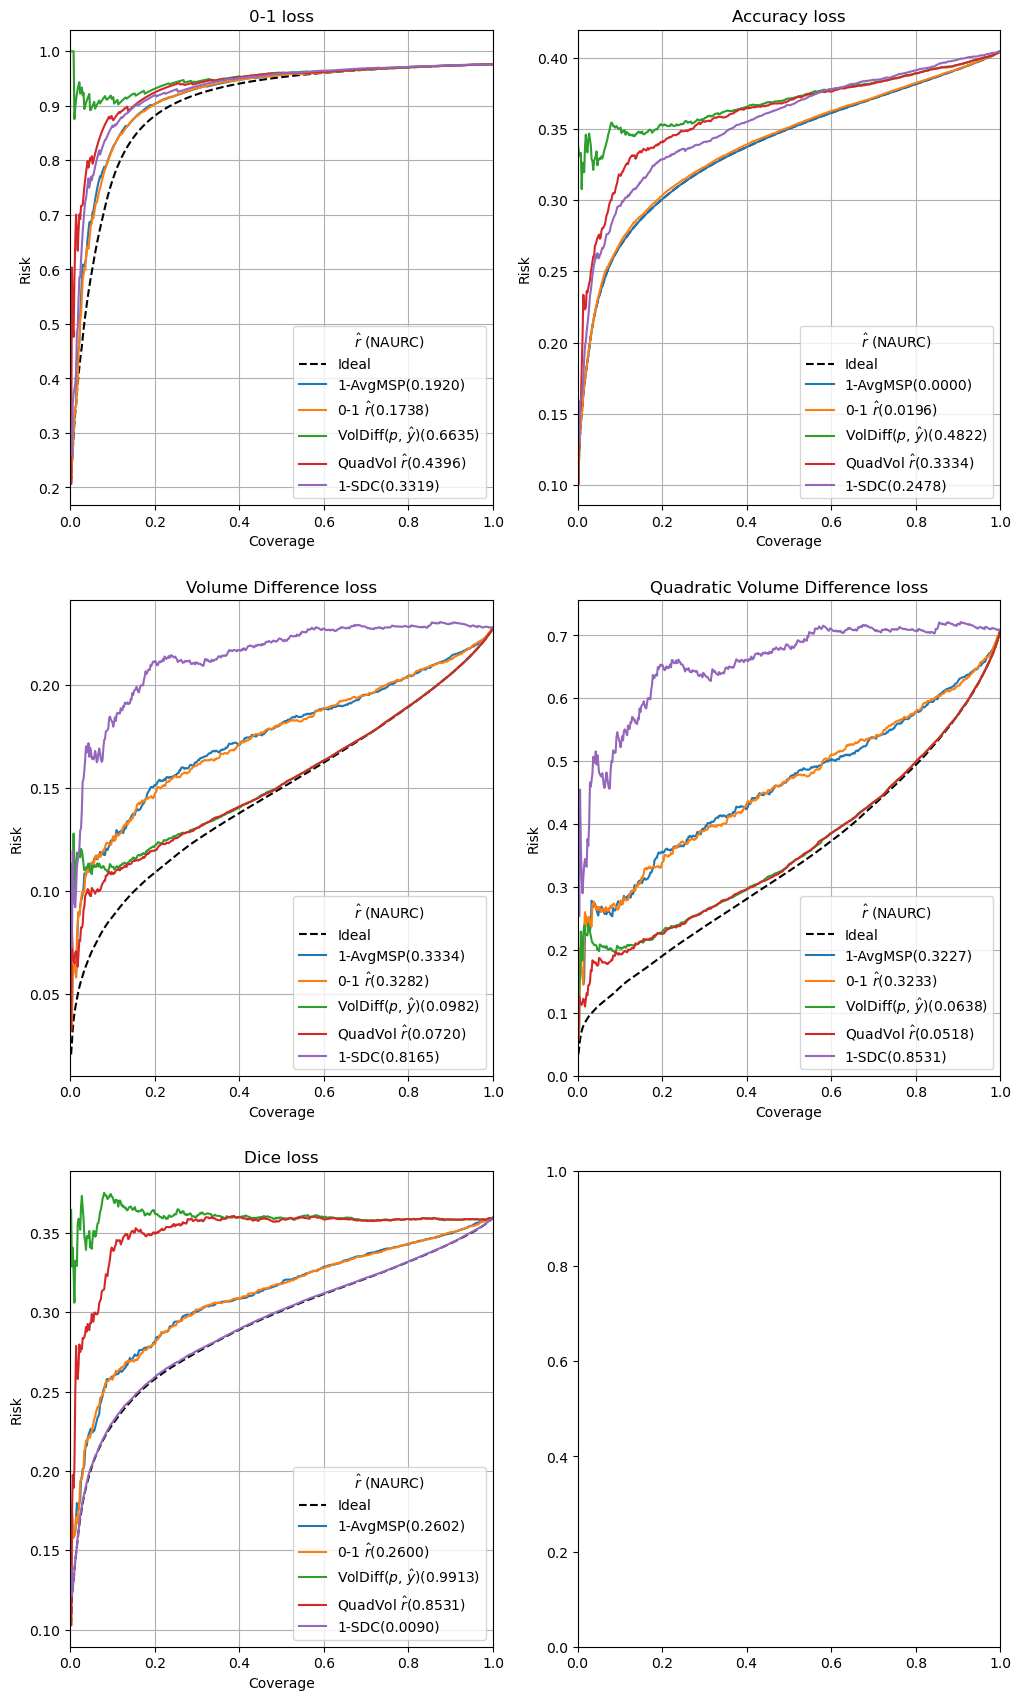

In [31]:
all_plots = [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]
# all_plots = [plot_01_rc,]
# fig, axs = plt.subplots(len(all_plots), 1, squeeze=True)
fig, axs = plt.subplots(int(len(all_plots)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(all_plots)/2 + 0.5))

for plot_rc, ax in zip(all_plots, axs.flatten()):
    plot_rc(h, Py, Pyi, ax=ax)
plt.show()

# Comments

TODO